Number of bands below Fermi level in DFT data: 20


(-3.0, 3.0)

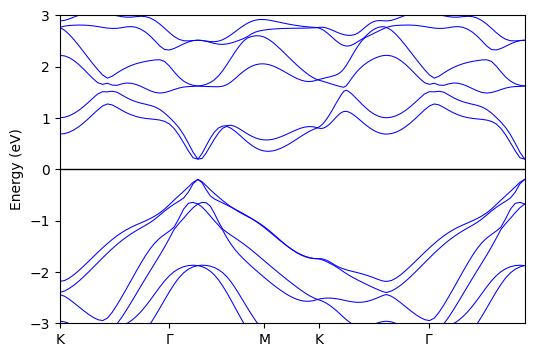

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data_dft = np.loadtxt("0-REFORMATTED_BAND.dat")

k_dft = data_dft[:, 0]
band_dft = data_dft[:, 1:]

high_symmetry_points = [0,0.780,1.456,1.846,2.626]
high_sym_labels = ['K',r'$\Gamma$','M', 'K', r'$\Gamma$',]

#number of bands below fermi level in DFT data
num_bands_below_fermi = np.sum(band_dft[0, :] < 0) 
print(f"Number of bands below Fermi level in DFT data: {num_bands_below_fermi}")

plt.figure(figsize=(6,4))

for i in range(band_dft.shape[1]):
    plt.plot(k_dft, band_dft[:, i], color='blue', linewidth=0.75, label='DFT' if i == 0 else "")
  
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

plt.xticks(high_symmetry_points, high_sym_labels)
plt.ylabel('Energy (eV)')
#plt.title('Band Structure for $\epsilon$ = 24', fontsize=16)
plt.xlim(min(k_dft), max(k_dft))
plt.ylim(-3, 3)

In [ ]:
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt


def parse_pband_file(path: Path) -> Tuple[np.ndarray, np.ndarray]:
    """Parse a PBAND_*_SOC.dat file and return k-points and band energies.

    Parameters
    ----------
    path : Path
        Path to a *-PBAND_*_SOC.dat file.

    Returns
    -------
    kpoints : (N_k,) ndarray
        1D array of k-path coordinates.
    energies : (N_bands, N_k) ndarray
        Energies (in eV) for each band along the k-path.
    """
    kpoints: List[float] = []
    bands: List[List[float]] = []
    current_band: List[float] = []
    current_band_index: int | None = None
    first_band_index: int | None = None

    with path.open("r", encoding="utf-8") as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue

            if line.startswith("#"):
                # Detect band boundaries
                if "Band-Index" in line:
                    # Finish previous band, if any
                    if current_band:
                        bands.append(current_band)
                        current_band = []

                    try:
                        current_band_index = int(line.split(":")[1].split()[0])
                    except (IndexError, ValueError):
                        current_band_index = None

                    if first_band_index is None and current_band_index is not None:
                        first_band_index = current_band_index

                continue

            # Data line: k, E, projections...
            parts = line.split()
            if len(parts) < 2:
                continue

            try:
                k = float(parts[0])
                e = float(parts[1])
            except ValueError:
                continue

            # Record k-path only for the first band; assumed identical for others
            if first_band_index is not None and current_band_index == first_band_index:
                kpoints.append(k)

            current_band.append(e)

    # Flush last band
    if current_band:
        bands.append(current_band)

    if not kpoints or not bands:
        raise ValueError(f"No k-points or bands parsed from {path}")

    k_arr = np.asarray(kpoints, dtype=float)
    energies = np.asarray(bands, dtype=float)

    # Ensure bands have consistent length
    if not np.all(np.array([len(b) for b in bands]) == k_arr.size):
        raise ValueError(f"Inconsistent band lengths in {path}")

    return k_arr, energies


def extract_strain_from_name(path: Path) -> float:
    """Extract strain value from filenames like '0-PBAND_Bi_SOC.dat'."""
    name = path.name
    first_token = name.split("-", 1)[0]
    try:
        return float(first_token)
    except ValueError:
        raise ValueError(f"Cannot parse strain from filename: {name}")


def load_series(base_dir: Path, element_tag: str) -> List[Dict]:
    """Load all *-PBAND_{element_tag}_SOC.dat files in base_dir."""
    files = sorted(base_dir.glob(f"*-PBAND_{element_tag}_SOC.dat"))
    series: List[Dict] = []

    for f in files:
        strain = extract_strain_from_name(f)
        kpoints, energies = parse_pband_file(f)
        series.append(
            {
                "strain": strain,
                "kpoints": kpoints,
                "energies": energies,
                "path": f,
            }
        )

    series.sort(key=lambda d: d["strain"])
    return series


def compute_gap(energies: np.ndarray) -> Tuple[float, float, float]:
    """Estimate band gap assuming energies are referenced to the Fermi level (E_F = 0)."""
    flat = energies.ravel()
    valence = flat[flat <= 0.0]
    conduction = flat[flat >= 0.0]

    if valence.size == 0 or conduction.size == 0:
        # Metallic or badly referenced: treat as zero-gap
        return 0.0, np.nan, np.nan

    vbm = float(valence.max())
    cbm = float(conduction.min())
    gap = cbm - vbm
    if gap < 0:
        gap = 0.0
    return gap, vbm, cbm


def plot_bands_for_series(series: List[Dict], element_tag: str) -> None:
    """Plot band structures for all strains in a given series on the same figure."""
    if not series:
        return

    # Assume shared k-path for all strains; use the first one
    k_ref = series[0]["kpoints"]

    cmap = plt.get_cmap("viridis")
    strains = np.array([s["strain"] for s in series], dtype=float)
    s_min, s_max = strains.min(), strains.max()
    norm = (strains - s_min) / (s_max - s_min) if s_max > s_min else np.zeros_like(strains)

    plt.figure(figsize=(6, 6))
    for s, color in zip(series, cmap(norm)):
        energies = s["energies"]
        for band in energies:
            plt.plot(k_ref, band, color=color, linewidth=0.6)

    sm = plt.cm.ScalarMappable(cmap=cmap)
    sm.set_array(strains)
    cbar = plt.colorbar(sm)
    cbar.set_label("Strain (from filename)")

    plt.xlabel("k-path coordinate")
    plt.ylabel("Energy (eV)")
    plt.title(f"Band structures vs strain (uniaxial-x, {element_tag})")
    plt.tight_layout()


def plot_gap_vs_strain(series: List[Dict], element_tag: str) -> None:
    """Plot estimated band gap vs strain for a given element."""
    if not series:
        return

    strains = []
    gaps = []
    for s in series:
        gap, _, _ = compute_gap(s["energies"])
        strains.append(s["strain"])
        gaps.append(gap)

    plt.figure(figsize=(5, 4))
    plt.plot(strains, gaps, marker="o")
    plt.xlabel("Strain (from filename)")
    plt.ylabel("Band gap (eV)")
    plt.title(f"Band gap vs strain (uniaxial-x, {element_tag})")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()


# Use the notebook directory (uniaxial-x) as the data directory
base_dir = Path.cwd()
print(f"Using data directory: {base_dir}")

bi_series = load_series(base_dir, "Bi")
sb_series = load_series(base_dir, "Sb")

print("Loaded files:")
for label, series in (("Bi", bi_series), ("Sb", sb_series)):
    print(f"  {label}:")
    for s in series:
        gap, vbm, cbm = compute_gap(s["energies"])
        print(
            f"    strain={s['strain']:6.2f}, gap={gap:7.3f} eV "
            f"(VBM={vbm:7.3f} eV, CBM={cbm:7.3f} eV) from {s['path'].name}"
        )

# Plot band structures and gaps vs strain for Bi and Sb
if bi_series:
    plot_bands_for_series(bi_series, "Bi")
    plot_gap_vs_strain(bi_series, "Bi")

if sb_series:
    plot_bands_for_series(sb_series, "Sb")
    plot_gap_vs_strain(sb_series, "Sb")


+----------------------------------------------------------------------+
| ===================                                                  |
| SURFACE CALCULATION                                                  |
| ===================                                                  |
| starting at 2026-01-06 15:13:18,069                                  |
| running Z2Pack version 2.2.1                                         |
|                                                                      |
| gap_tol:            0.3                                              |
| init_result:        None                                             |
| iterator:           range(30, 101, 5)                                |
| load:               False                                            |
| load_quiet:         True                                             |
| min_neighbour_dist: 0.01                                             |
| move_tol:           0.3                         

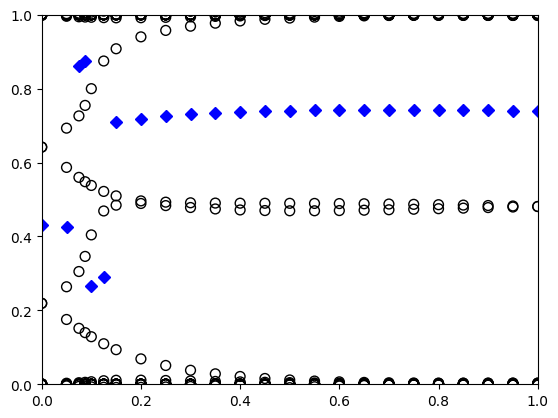

In [4]:
import z2pack
import tbmodels # type: ignore
import matplotlib.pyplot as plt

model = tbmodels.Model.from_wannier_files(hr_file='18-wannier90_hr.dat', wsvec_file='18-wannier90_wsvec.dat',occ=20)

system = z2pack.tb.System(model)
result = z2pack.surface.run(system=system, surface=lambda t1,t2: [t1/2, t2, 0.5],num_lines=21,iterator=range(30, 101, 5))

z2pack.plot.wcc(result)
print(z2pack.invariant.z2(result))
plt.show()

C:\Users\furka\AppData\Local\Temp\ipykernel_3108\2168334018.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, comment='#', delim_whitespace=True, header=None, skiprows=2)
C:\Users\furka\AppData\Local\Temp\ipykernel_3108\2168334018.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, comment='#', delim_whitespace=True, header=None, skiprows=2)


Global Maximum Weight found: 0.73
[array([0.     , 0.03389, 0.06778, ..., 3.2404 , 3.27429, 3.30818]), array([-24.633088, -24.633098, -24.633101, ...,   5.403941,   5.38957 ,
         5.384853]), array([0.        , 0.        , 0.        , ..., 0.00547945, 0.00547945,
       0.00547945]), array([0., 0., 0., ..., 0., 0., 0.]), array([0.        , 0.        , 0.        , ..., 0.00273973, 0.00273973,
       0.00273973]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0.        , 0.        , 0.        , ..., 0.00273973, 0.00273973,
       0.00273973]), array([0., 0., 0., ..., 0., 0., 0.])]


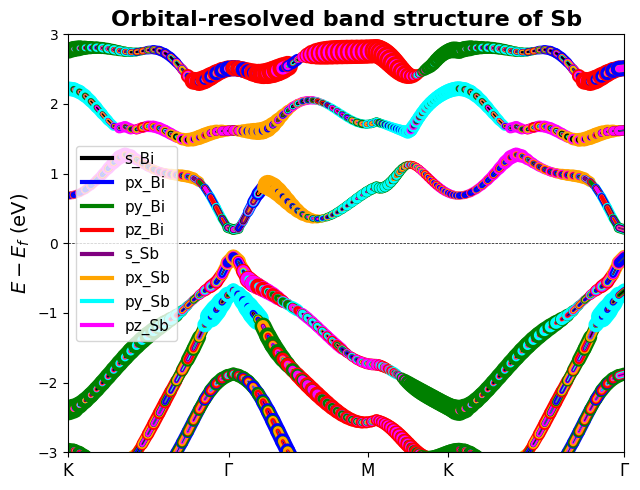

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define Filenames ---
file_Bi = "0-PBAND_Bi_SOC.dat"
file_Sb = "0-PBAND_Sb_SOC.dat"

# --- 2. Function to Read and Sum Orbitals ---
def get_atom_data(filename):
    # Read file, skipping header (lines 0,1)
    # Assumes columns: 0=k, 1=energy, 2=s, 3=px, 4=py, 5=pz ...
    df = pd.read_csv(filename, comment='#', delim_whitespace=True, header=None, skiprows=2)
    
    # Get K and Energy
    k = df[0].to_numpy()
    e = df[1].to_numpy()
    s = df[2].to_numpy()
    px = df[3].to_numpy()
    py = df[4].to_numpy()
    pz = df[5].to_numpy()

    return k, e, s, px, py, pz

# --- 3. Load Data ---
k_points, energies, s_Bi, px_Bi, py_Bi, pz_Bi = get_atom_data(file_Bi)
_, _, s_Sb, px_Sb, py_Sb, pz_Sb = get_atom_data(file_Sb) # We only need weights from the second file


# --- 4. Global Scaling ---
# Find the absolute maximum value appearing in EITHER file
max_val_Bi = np.max([max(s_Bi), max(px_Bi), max(py_Bi), max(pz_Bi)])
max_val_Sb = np.max([max(s_Sb), max(px_Sb), max(py_Sb), max(pz_Sb)])
global_max = max(max_val_Bi, max_val_Sb)

print(f"Global Maximum Weight found: {global_max}")

# Divide both by the same number so they are comparable
s_Bi_scaled = s_Bi / global_max
px_Bi_scaled = px_Bi / global_max
py_Bi_scaled = py_Bi / global_max
pz_Bi_scaled = pz_Bi / global_max
s_Sb_scaled = s_Sb / global_max
px_Sb_scaled = px_Sb / global_max
py_Sb_scaled = py_Sb / global_max
pz_Sb_scaled = pz_Sb / global_max

main_data = [k_points, energies, s_Bi_scaled, px_Bi_scaled, py_Bi_scaled, pz_Bi_scaled, s_Sb_scaled, px_Sb_scaled, py_Sb_scaled, pz_Sb_scaled]

print(main_data)

#identify individual bands
bands_k = []
bands_e = []
bands_s_Bi = []
bands_px_Bi = []
bands_py_Bi = []
bands_pz_Bi = []
bands_s_Sb = []
bands_px_Sb = []
bands_py_Sb = []
bands_pz_Sb = []

current_band_k = [k_points[0]]
current_band_e = [energies[0]]
current_band_s_Bi = [s_Bi[0]]
current_band_px_Bi = [px_Bi[0]]
current_band_py_Bi = [py_Bi[0]]
current_band_pz_Bi = [pz_Bi[0]]
current_band_s_Sb = [s_Sb[0]]
current_band_px_Sb = [px_Sb[0]]
current_band_py_Sb = [py_Sb[0]]
current_band_pz_Sb = [pz_Sb[0]]

for i in range(1, len(k_points)):
    if k_points[i] <= k_points[i-1]:
        bands_k.append(np.array(current_band_k))
        bands_e.append(np.array(current_band_e))
        bands_s_Bi.append(np.array(current_band_s_Bi))
        bands_px_Bi.append(np.array(current_band_px_Bi))
        bands_py_Bi.append(np.array(current_band_py_Bi))
        bands_pz_Bi.append(np.array(current_band_pz_Bi))
        bands_s_Sb.append(np.array(current_band_s_Sb))
        bands_px_Sb.append(np.array(current_band_px_Sb))
        bands_py_Sb.append(np.array(current_band_py_Sb))
        bands_pz_Sb.append(np.array(current_band_pz_Sb))

        current_band_k = [k_points[i]]
        current_band_e = [energies[i]]
        current_band_s_Bi = [s_Bi[i]]
        current_band_px_Bi = [px_Bi[i]]
        current_band_py_Bi = [py_Bi[i]]
        current_band_pz_Bi = [pz_Bi[i]]
        current_band_s_Sb = [s_Sb[i]]
        current_band_px_Sb = [px_Sb[i]]
        current_band_py_Sb = [py_Sb[i]]
        current_band_pz_Sb = [pz_Sb[i]]
    else:
        current_band_k.append(k_points[i])
        current_band_e.append(energies[i])
        current_band_s_Bi.append(s_Bi[i])
        current_band_px_Bi.append(px_Bi[i])
        current_band_py_Bi.append(py_Bi[i])
        current_band_pz_Bi.append(pz_Bi[i])
        current_band_s_Sb.append(s_Sb[i])
        current_band_px_Sb.append(px_Sb[i])
        current_band_py_Sb.append(py_Sb[i])
        current_band_pz_Sb.append(pz_Sb[i])

bands_k.append(np.array(current_band_k))
bands_e.append(np.array(current_band_e))
bands_s_Bi.append(np.array(current_band_s_Bi))
bands_px_Bi.append(np.array(current_band_px_Bi))
bands_py_Bi.append(np.array(current_band_py_Bi))
bands_pz_Bi.append(np.array(current_band_pz_Bi))
bands_s_Sb.append(np.array(current_band_s_Sb))
bands_px_Sb.append(np.array(current_band_px_Sb))
bands_py_Sb.append(np.array(current_band_py_Sb))
bands_pz_Sb.append(np.array(current_band_pz_Sb))

# Create single plot
fig, ax = plt.subplots(figsize=(6.5, 5))

orbitals_list = [bands_s_Bi, bands_px_Bi, bands_py_Bi, bands_pz_Bi,
                 bands_s_Sb, bands_px_Sb, bands_py_Sb, bands_pz_Sb]
colors = ['black', 'blue', 'green', 'red', 'purple', 'orange', 'cyan', 'magenta']
names = ['s_Bi', 'px_Bi', 'py_Bi', 'pz_Bi', 's_Sb', 'px_Sb', 'py_Sb', 'pz_Sb']

width_scale = 70

# Plot each band
for i in range(len(bands_k)):
    k_band = bands_k[i]
    e_band = bands_e[i]
    
    # For each segment, collect all orbital contributions and sort by size
    for j in range(len(k_band) - 1):
        # Get contributions from all orbitals for this segment
        contributions = [
            ((bands_s_Bi[i][j] + bands_s_Bi[i][j+1]) / 2, 'black', 's_Bi'),
            ((bands_px_Bi[i][j] + bands_px_Bi[i][j+1]) / 2, 'blue', 'px_Bi'),
            ((bands_py_Bi[i][j] + bands_py_Bi[i][j+1]) / 2, 'green', 'py_Bi'),
            ((bands_pz_Bi[i][j] + bands_pz_Bi[i][j+1]) / 2, 'red', 'pz_Bi'),
            ((bands_s_Sb[i][j] + bands_s_Sb[i][j+1]) / 2, 'purple', 's_Sb'),
            ((bands_px_Sb[i][j] + bands_px_Sb[i][j+1]) / 2, 'orange', 'px_Sb'),
            ((bands_py_Sb[i][j] + bands_py_Sb[i][j+1]) / 2, 'cyan', 'py_Sb'),
            ((bands_pz_Sb[i][j] + bands_pz_Sb[i][j+1]) / 2, 'magenta', 'pz_Sb')
        ]
        
        # Sort by contribution (largest first, so it's drawn first/on bottom)
        contributions.sort(reverse=True, key=lambda x: x[0])
        
        # Plot each orbital contribution in order (largest to smallest)
        for contrib, color, label in contributions:
            lw = contrib * width_scale
            if lw > 0.1:
                ax.plot(k_band[j:j+2], e_band[j:j+2], 
                       color=color, linewidth=lw, alpha=1, 
                       solid_capstyle='round', zorder=1)

# Add thin background lines to show all bands
for i in range(len(bands_k)):
    ax.plot(bands_k[i], bands_e[i], color='black', linewidth=0.5, alpha=0.3, zorder=0)

ax.set_title('Orbital-resolved band structure of Sb', fontsize=16, fontweight='bold')
ax.set_ylim(-3, 3)
ax.set_xlim(min(k_points), max(k_points))
ax.set_ylabel(r'$E-E_f$ (eV)', fontsize=14)

# Add grid lines
ax.axhline(0, ls='--', lw=0.5, color='black', zorder=0)

# X-axis labels
ax.set_xticks([0, 0.954, 1.781, 2.258, max(k_points)])
ax.set_xticklabels(['K', '$\Gamma$', 'M', 'K', '$\Gamma$'], fontsize=12)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', lw=3, label='s_Bi'),
    Line2D([0], [0], color='blue', lw=3, label='px_Bi'),
    Line2D([0], [0], color='green', lw=3, label='py_Bi'),
    Line2D([0], [0], color='red', lw=3, label='pz_Bi'),
    Line2D([0], [0], color='purple', lw=3, label='s_Sb'),
    Line2D([0], [0], color='orange', lw=3, label='px_Sb'),
    Line2D([0], [0], color='cyan', lw=3, label='py_Sb'),
    Line2D([0], [0], color='magenta', lw=3, label='pz_Sb')
]
ax.legend(handles=legend_elements, loc='best', fontsize=11)

plt.tight_layout()
plt.show()

C:\Users\furka\AppData\Local\Temp\ipykernel_10360\1549829525.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, comment='#', delim_whitespace=True, header=None, skiprows=2)


Plotting Vivid Mode...


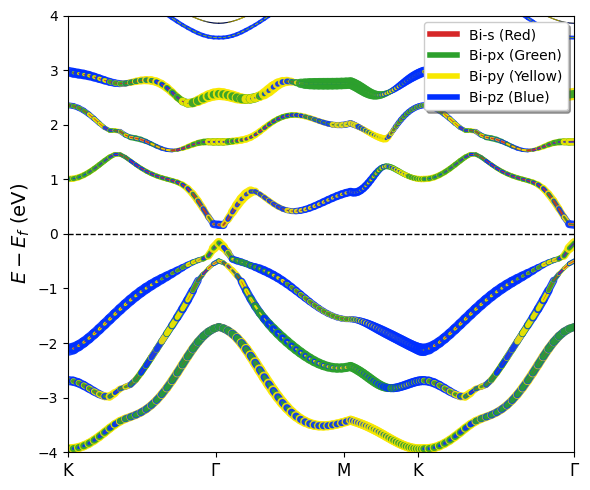

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- 1. Define Filenames ---
file = "4-PBAND_Bi_SOC.dat"

# --- 2. Load Data Function ---
def get_detailed_atom_data(filename):
    df = pd.read_csv(filename, comment='#', delim_whitespace=True, header=None, skiprows=2)
    k = df[0].to_numpy()
    e = df[1].to_numpy()
    return k, e, df[2].to_numpy(), df[3].to_numpy(), df[4].to_numpy(), df[5].to_numpy()

# --- 3. Load Data ---
k_pts, eng, s, py, pz, px = get_detailed_atom_data(file)


# --- 5. VIVID COLOR CONFIGURATION ---
# Using Hex codes for maximum saturation and distinctness
# Bi (Warm/Darker tones) | Sb (Cool/Bright tones)
orbital_data = [
    # Data   Color      Label
    (s,  '#D62728', 'Bi-s (Red)'),      # Vivid Red  # Vivid Orange  # Brown    # Pink    
    (px, '#2CA02C', 'Bi-px (Green)'),   # Vivid Green    # Cyan
    (py, "#F8E800", 'Bi-py (Yellow)'),  # Vivid Orange
    (pz, "#002FFF", 'Bi-pz (Blue)'),  # Purple
]

# --- 6. Band Splitting ---
band_indices = []
start_index = 0
for i in range(1, len(k_pts)):
    if k_pts[i] <= k_pts[i-1]:
        band_indices.append((start_index, i))
        start_index = i
band_indices.append((start_index, len(k_pts)))

# --- 7. Plotting ---
fig, ax = plt.subplots(figsize=(6, 5))

# SETTINGS FOR "PUNCHY" LOOK
width_scale = 9       # Slightly lower because lines are solid now
alpha_constant = 0.9   # High opacity (nearly solid)
power_scale = 0.7      # <1.0 makes thin lines thicker (Boosts visibility)

print("Plotting Vivid Mode...")

for start, end in band_indices:
    k_band = k_pts[start:end]
    e_band = eng[start:end]
    
    for j in range(len(k_band) - 1):
        segment_contribs = []
        
        # Calculate weights
        for w_arr, color, label in orbital_data:
            idx = start + j
            raw_w = (w_arr[idx] + w_arr[idx+1]) / 2
            norm_w = raw_w / np.max(w_arr)
            segment_contribs.append((norm_w, color))
            
        # Sort: Thickest lines on BOTTOM, thinnest on TOP
        # This prevents the fat lines from covering the details of thin lines
        segment_contribs.sort(reverse=True, key=lambda x: x[0])
        
        for norm_w, color in segment_contribs:
            # NON-LINEAR SCALING: Boosts low-weight visibility
            # If weight is 0.1, visual thickness becomes 0.1^0.6 = 0.25 (2.5x boost)
            # If weight is 1.0, visual thickness stays 1.0
            boosted_w = np.power(norm_w, power_scale)
            
            lw = boosted_w * width_scale
            
            if lw > 0.2: # Only draw if visible
                ax.plot(k_band[j:j+2], e_band[j:j+2], 
                        color=color, 
                        linewidth=lw, 
                        alpha=alpha_constant, # Constant solid alpha
                        solid_capstyle='round', 
                        zorder=1)

# Skeleton (Black line behind everything to define the path)
for start, end in band_indices:
    ax.plot(k_pts[start:end], eng[start:end], color='black', lw=0.8, alpha=1.0, zorder=0)

# --- 8. Formatting ---
ax.set_ylim(-4, 4)
ax.set_xlim(min(k_pts), max(k_pts))
ax.set_ylabel(r'$E-E_f$ (eV)', fontsize=14)
ax.axhline(0, ls='--', lw=1, color='black')
ax.set_xticks([0, 0.954, 1.781, 2.258, max(k_pts)])
ax.set_xticklabels(['K', '$\Gamma$', 'M', 'K', '$\Gamma$'], fontsize=12)
# Set a light gray background to make colors pop even more (Optional)
# ax.set_facecolor('#F0F0F0') 

# Legend
legend_elements = [Line2D([0], [0], color=c, lw=4, label=l) for _, c, l in orbital_data]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=1, shadow=True)

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os

# ==========================================
# 1. CONFIGURATION SECTION
# ==========================================

# Add your files here in the format: (File_Number, "Atom_Name")
# The code assumes filenames look like: "{number}-PBAND_{atom}_SOC.dat"
file_targets = [
    ("0", "Bi"),
    ("2", "Bi"),
    ("4", "Bi"),
    ("6", "Bi"),
    ("8", "Bi"),
    ("10", "Bi"),
    ("12", "Bi"),
    ("14", "Bi"),
    ("16", "Bi"),
    ("18", "Bi"),
    ("20", "Bi"),
    ("22", "Bi"),
    ("24", "Bi"),
    ("26", "Bi"),
    ("0", "Sb"),
    ("2", "Sb"),
    ("4", "Sb"),
    ("6", "Sb"),
    ("8", "Sb"),
    ("10", "Sb"),
    ("12", "Sb"),
    ("14", "Sb"),
    ("16", "Sb"),
    ("18", "Sb"),
    ("20", "Sb"),
    ("22", "Sb"),
    ("24", "Sb"),
    ("26", "Sb"),
]

# Shared Plot Settings
Y_LIM = (-4, 4)
XTICK_LABELS = ['K', '$\Gamma$', 'M', 'K', '$\Gamma$']
# XTICK_POSITIONS will be calculated dynamically from the data, 
# or you can hardcode them if they are identical for all files.

# ==========================================
# 2. FUNCTIONS
# ==========================================

def get_detailed_atom_data(filename):
    """Loads k-points, energy, and orbital projections from the file."""
    try:
        df = pd.read_csv(filename, comment='#', delim_whitespace=True, header=None, skiprows=2)
        k = df[0].to_numpy()
        e = df[1].to_numpy()
        # Returns: k, e, s, py, pz, px
        return k, e, df[2].to_numpy(), df[3].to_numpy(), df[4].to_numpy(), df[5].to_numpy()
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found. Skipping...")
        return None

def get_band_segments(k_pts):
    """Identifies where the band path breaks (discontinuities in k-space)."""
    band_indices = []
    start_index = 0
    for i in range(1, len(k_pts)):
        if k_pts[i] <= k_pts[i-1]:
            band_indices.append((start_index, i))
            start_index = i
    band_indices.append((start_index, len(k_pts)))
    return band_indices

# ==========================================
# 3. MAIN LOOP
# ==========================================

for file_num, atom_name in file_targets:
    # Construct filename dynamically
    filename = f"{file_num}-PBAND_{atom_name}_SOC.dat"
    print(f"\nProcessing: {filename}...")

    # Load Data
    data = get_detailed_atom_data(filename)
    if data is None: continue # Skip if file doesn't exist

    k_pts, eng, s, py, pz, px = data

    # Define Orbitals with Dynamic Labels
    # Bi/Sb (Warm/Darker tones) | (Cool/Bright tones)
    orbital_data = [
        # Data    Color       Label
        (s,  '#D62728', f'{atom_name}-s'), 
        (px, '#2CA02C', f'{atom_name}-px'), 
        (py, "#F8E800", f'{atom_name}-py'), 
        (pz, "#002FFF", f'{atom_name}-pz'), 
    ]

    # Get Band Segments
    band_indices = get_band_segments(k_pts)

    # Setup Plot
    fig, ax = plt.subplots(figsize=(6, 5))

    # SETTINGS FOR "PUNCHY" LOOK
    width_scale = 9       
    alpha_constant = 0.9   
    power_scale = 0.7      

    # Plot Colored Segments
    for start, end in band_indices:
        k_band = k_pts[start:end]
        e_band = eng[start:end]
        
        for j in range(len(k_band) - 1):
            segment_contribs = []
            
            # Calculate weights
            for w_arr, color, label in orbital_data:
                idx = start + j
                # Average weight between two points
                raw_w = (w_arr[idx] + w_arr[idx+1]) / 2
                # Normalize by max weight of that orbital type across the whole file
                norm_w = raw_w / (np.max(w_arr) + 1e-9) # Avoid divide by zero
                segment_contribs.append((norm_w, color))
            
            # Sort: Thickest lines on BOTTOM
            segment_contribs.sort(reverse=True, key=lambda x: x[0])
            
            for norm_w, color in segment_contribs:
                # Non-linear scaling
                boosted_w = np.power(norm_w, power_scale)
                lw = boosted_w * width_scale
                
                if lw > 0.2: # Optimization: Don't draw invisible lines
                    ax.plot(k_band[j:j+2], e_band[j:j+2], 
                            color=color, 
                            linewidth=lw, 
                            alpha=alpha_constant, 
                            solid_capstyle='round', 
                            zorder=1)

    # Skeleton (Black line)
    for start, end in band_indices:
        ax.plot(k_pts[start:end], eng[start:end], color='black', lw=0.8, alpha=1.0, zorder=0)

    # Formatting
    ax.set_ylim(Y_LIM)
    ax.set_xlim(min(k_pts), max(k_pts))
    ax.set_ylabel(r'$E-E_f$ (eV)', fontsize=14)
    ax.axhline(0, ls='--', lw=1, color='black')
    
    # X-Ticks (Assuming standard path points)
    # Note: If your high-symmetry points differ per file, calculate them from k_pts
    xtick_locs = [0, 0.954, 1.781, 2.258, max(k_pts)] 
    ax.set_xticks(xtick_locs)
    ax.set_xticklabels(XTICK_LABELS, fontsize=12)

    # Legend
    legend_elements = [Line2D([0], [0], color=c, lw=4, label=l) for _, c, l in orbital_data]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=1, shadow=True)

    plt.tight_layout()
    
    # Save file
    output_png = f"Band_Structure_{atom_name}_{file_num}.png"
    plt.savefig(output_png, dpi=300)
    print(f"Saved: {output_png}")
    
    # Clear memory
    plt.close(fig) 

print("\nAll plots generated!")


Processing: 0-PBAND_Bi_SOC.dat...


C:\Users\furka\AppData\Local\Temp\ipykernel_2460\3831739212.py:57: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, comment='#', delim_whitespace=True, header=None, skiprows=2)


Saved: Band_Structure_Bi_0.png

Processing: 2-PBAND_Bi_SOC.dat...


C:\Users\furka\AppData\Local\Temp\ipykernel_2460\3831739212.py:57: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, comment='#', delim_whitespace=True, header=None, skiprows=2)


Saved: Band_Structure_Bi_2.png

Processing: 4-PBAND_Bi_SOC.dat...


...

Saved: Band_Structure_Sb_22.png

Processing: 24-PBAND_Sb_SOC.dat...


C:\Users\furka\AppData\Local\Temp\ipykernel_2460\3831739212.py:57: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, comment='#', delim_whitespace=True, header=None, skiprows=2)


Saved: Band_Structure_Sb_24.png

Processing: 26-PBAND_Sb_SOC.dat...


C:\Users\furka\AppData\Local\Temp\ipykernel_2460\3831739212.py:57: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, comment='#', delim_whitespace=True, header=None, skiprows=2)


Saved: Band_Structure_Sb_26.png

All plots generated!


Loading data...
Global max weight: 0.7300
Found 1988 band segments
Rendering fatbands in 'dominant' mode...


C:\Users\furka\AppData\Local\Temp\ipykernel_20448\4062605082.py:112: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, comment='#', delim_whitespace=True,
C:\Users\furka\AppData\Local\Temp\ipykernel_20448\4062605082.py:112: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, comment='#', delim_whitespace=True,


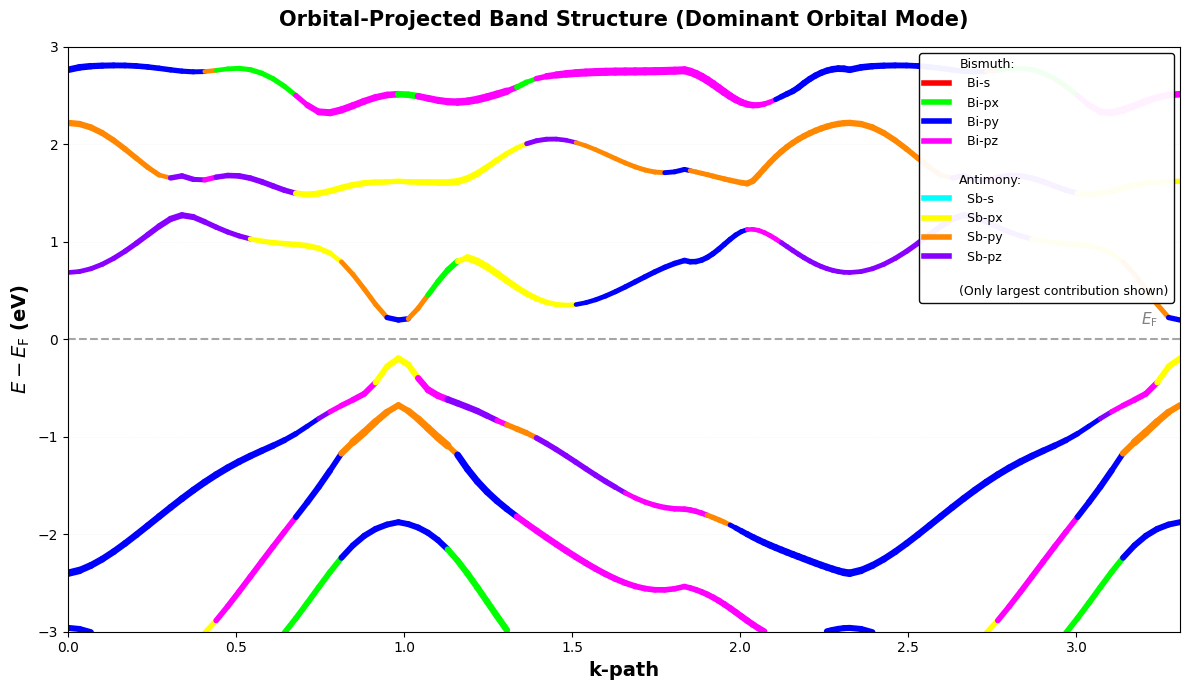

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb

# =============================================================================
# CONFIGURATION
# =============================================================================

# File paths
file_Bi = "0-PBAND_Bi_SOC.dat"
file_Sb = "0-PBAND_Sb_SOC.dat"

# Visualization mode - CHOOSE ONE:
MODE = "dominant"  # Options: "blended", "dominant", "layered"
# - "blended": Mix colors proportionally (shows mixed character clearly)
# - "dominant": Only show the largest contribution (cleanest, simplest)
# - "layered": Original approach (can be confusing with overlaps)

COLOR_SCHEME = "okabe_ito"
# Choose one: "rgb_cmy", "warm_cool", "spectral", "okabe_ito"

# Visualization settings
HIGH_PASS_THRESHOLD = 0.02  # Filter out contributions below 2% of max
ENERGY_WINDOW = (-3, 3)     # Energy range to display (eV)
WIDTH_SCALE = 10            # Maximum line width
POWER_SCALE = 0.5           # Nonlinear scaling (< 1 boosts thin lines)
ALPHA = 1                 # Line opacity
SKELETON_WIDTH = 0.5        # Background guide line width

# High-symmetry points (edit these based on your k-path)


# =============================================================================
# COLOR SCHEME SELECTION
# =============================================================================
# Choose one: "rgb_cmy", "warm_cool", "spectral", "okabe_ito"

COLOR_SCHEME = "rgb_cmy"

if COLOR_SCHEME == "rgb_cmy":
    # RGB + CMY: Maximum contrast, intuitive color mixing
    # Best for "blended" mode - creates predictable intermediate colors
    orbital_config = [
        # Bismuth: Primary colors (RGB)
        {'label': 'Bi-s',  'color': '#FF0000', 'atom': 'Bi'},  # Pure Red
        {'label': 'Bi-px', 'color': '#00FF00', 'atom': 'Bi'},  # Pure Green
        {'label': 'Bi-py', 'color': '#0000FF', 'atom': 'Bi'},  # Pure Blue
        {'label': 'Bi-pz', 'color': '#FF00FF', 'atom': 'Bi'},  # Magenta
        
        # Antimony: Secondary colors (CMY)
        {'label': 'Sb-s',  'color': '#00FFFF', 'atom': 'Sb'},  # Cyan
        {'label': 'Sb-px', 'color': '#FFFF00', 'atom': 'Sb'},  # Yellow
        {'label': 'Sb-py', 'color': '#FF8800', 'atom': 'Sb'},  # Orange
        {'label': 'Sb-pz', 'color': '#8800FF', 'atom': 'Sb'},  # Violet
    ]

elif COLOR_SCHEME == "warm_cool":
    # Warm vs Cool: Best for distinguishing atoms at a glance
    # Temperature clearly indicates Bi (hot) vs Sb (cold)
    orbital_config = [
        # Bismuth: Warm colors (fire spectrum)
        {'label': 'Bi-s',  'color': '#FF0000', 'atom': 'Bi'},  # Red
        {'label': 'Bi-px', 'color': '#FF6600', 'atom': 'Bi'},  # Red-Orange
        {'label': 'Bi-py', 'color': '#FF9900', 'atom': 'Bi'},  # Orange
        {'label': 'Bi-pz', 'color': '#FFCC00', 'atom': 'Bi'},  # Gold
        
        # Antimony: Cool colors (ice spectrum)
        {'label': 'Sb-s',  'color': '#0066FF', 'atom': 'Sb'},  # Blue
        {'label': 'Sb-px', 'color': '#0099FF', 'atom': 'Sb'},  # Sky Blue
        {'label': 'Sb-py', 'color': '#00CCCC', 'atom': 'Sb'},  # Cyan
        {'label': 'Sb-pz', 'color': '#00FF99', 'atom': 'Sb'},  # Aqua
    ]

elif COLOR_SCHEME == "spectral":
    # Spectral/Rainbow: Maps orbital progression (s→p) to spectrum
    # Both atoms use same hue sequence, different saturation
    orbital_config = [
        # Bismuth: Vivid/saturated rainbow
        {'label': 'Bi-s',  'color': '#FF0000', 'atom': 'Bi'},  # Red (s)
        {'label': 'Bi-px', 'color': '#00FF00', 'atom': 'Bi'},  # Green (px)
        {'label': 'Bi-py', 'color': '#0000FF', 'atom': 'Bi'},  # Blue (py)
        {'label': 'Bi-pz', 'color': '#FF00FF', 'atom': 'Bi'},  # Magenta (pz)
        
        # Antimony: Pastel/desaturated rainbow
        {'label': 'Sb-s',  'color': '#FF6666', 'atom': 'Sb'},  # Light Red
        {'label': 'Sb-px', 'color': '#66FF66', 'atom': 'Sb'},  # Light Green
        {'label': 'Sb-py', 'color': '#6666FF', 'atom': 'Sb'},  # Light Blue
        {'label': 'Sb-pz', 'color': '#FF66FF', 'atom': 'Sb'},  # Light Magenta
    ]

elif COLOR_SCHEME == "okabe_ito":
    # Original Okabe-Ito (colorblind-friendly but less intuitive blending)
    orbital_config = [
        {'label': 'Bi-s',  'color': '#E69F00', 'atom': 'Bi'},  # Orange
        {'label': 'Bi-px', 'color': '#D55E00', 'atom': 'Bi'},  # Vermillion
        {'label': 'Bi-py', 'color': '#CC79A7', 'atom': 'Bi'},  # Pink
        {'label': 'Bi-pz', 'color': '#882255', 'atom': 'Bi'},  # Purple
        {'label': 'Sb-s',  'color': '#0072B2', 'atom': 'Sb'},  # Blue
        {'label': 'Sb-px', 'color': '#009E73', 'atom': 'Sb'},  # Green
        {'label': 'Sb-py', 'color': '#56B4E9', 'atom': 'Sb'},  # Sky blue
        {'label': 'Sb-pz', 'color': '#00A9A5', 'atom': 'Sb'},  # Teal
    ]

# =============================================================================
# DATA LOADING
# =============================================================================

def load_orbital_data(filename):
    """Load orbital-projected band structure data from VASPKit output."""
    df = pd.read_csv(filename, comment='#', delim_whitespace=True, 
                     header=None, skiprows=2)
    return {
        'k': df[0].to_numpy(),
        'e': df[1].to_numpy(),
        's': df[2].to_numpy(),
        'px': df[3].to_numpy(),
        'py': df[4].to_numpy(),
        'pz': df[5].to_numpy()
    }

print("Loading data...")
data_Bi = load_orbital_data(file_Bi)
data_Sb = load_orbital_data(file_Sb)

k_pts = data_Bi['k']
eng = data_Bi['e']

# Combine all orbital weights
orbital_weights = [
    data_Bi['s'], data_Bi['px'], data_Bi['py'], data_Bi['pz'],
    data_Sb['s'], data_Sb['px'], data_Sb['py'], data_Sb['pz']
]

# Global normalization
global_max = max(np.max(w) for w in orbital_weights)
print(f"Global max weight: {global_max:.4f}")

# =============================================================================
# COLOR MIXING UTILITIES
# =============================================================================

def blend_colors(colors, weights):
    """
    Blend multiple colors proportionally by their weights.
    Returns an RGB tuple.
    """
    if len(colors) == 0:
        return (0, 0, 0)
    
    # Convert hex colors to RGB
    rgb_colors = np.array([to_rgb(c) for c in colors])
    weights = np.array(weights)
    
    # Normalize weights
    weights = weights / weights.sum()
    
    # Weighted average in RGB space
    blended = np.sum(rgb_colors * weights[:, np.newaxis], axis=0)
    
    # Clip to valid range [0, 1] to avoid floating point errors
    blended = np.clip(blended, 0.0, 1.0)
    
    return tuple(blended)

# =============================================================================
# BAND SEGMENTATION
# =============================================================================

def find_band_segments(k_points):
    """Identify separate bands (k-path breaks)."""
    segments = []
    start = 0
    
    for i in range(1, len(k_points)):
        if k_points[i] <= k_points[i-1]:  # k-point wraps back
            segments.append((start, i))
            start = i
    segments.append((start, len(k_points)))
    
    return segments

band_segments = find_band_segments(k_pts)
print(f"Found {len(band_segments)} band segments")

# =============================================================================
# PLOTTING
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 7))

print(f"Rendering fatbands in '{MODE}' mode...")

# Plot each band segment
for start, end in band_segments:
    k_band = k_pts[start:end]
    e_band = eng[start:end]
    
    # Plot each line segment
    for j in range(len(k_band) - 1):
        # Skip if outside energy window
        e_avg = (e_band[j] + e_band[j+1]) / 2
        if e_avg < ENERGY_WINDOW[0] or e_avg > ENERGY_WINDOW[1]:
            continue
        
        # Collect all orbital contributions for this segment
        contributions = []
        
        for idx, (w_arr, config) in enumerate(zip(orbital_weights, orbital_config)):
            raw_w = (w_arr[start + j] + w_arr[start + j + 1]) / 2
            norm_w = raw_w / global_max
            
            # High-pass filter
            if norm_w < HIGH_PASS_THRESHOLD:
                continue
            
            contributions.append({
                'weight': norm_w,
                'color': config['color'],
                'label': config['label']
            })
        
        if len(contributions) == 0:
            continue
        
        # Sort by weight (descending)
        contributions.sort(reverse=True, key=lambda x: x['weight'])
        
        # =================================================================
        # MODE-SPECIFIC RENDERING
        # =================================================================
        
        if MODE == "blended":
            # BLENDED MODE: Mix colors proportionally
            colors = [c['color'] for c in contributions]
            weights = [c['weight'] for c in contributions]
            
            # Calculate blended color
            blended_color = blend_colors(colors, weights)
            
            # Total weight determines line thickness
            total_weight = sum(weights)
            scaled_w = np.power(total_weight, POWER_SCALE)
            lw = scaled_w * WIDTH_SCALE
            
            ax.plot(k_band[j:j+2], e_band[j:j+2],
                   color=blended_color,
                   linewidth=lw,
                   alpha=ALPHA,
                   solid_capstyle='round',
                   zorder=2)
        
        elif MODE == "dominant":
            # DOMINANT MODE: Only show the largest contribution
            dominant = contributions[0]
            
            scaled_w = np.power(dominant['weight'], POWER_SCALE)
            lw = scaled_w * WIDTH_SCALE
            
            ax.plot(k_band[j:j+2], e_band[j:j+2],
                   color=dominant['color'],
                   linewidth=lw,
                   alpha=ALPHA,
                   solid_capstyle='round',
                   zorder=2)
        
        elif MODE == "layered":
            # LAYERED MODE: Draw all contributions (original approach)
            # Draw thickest first (on bottom)
            for contrib in contributions:
                scaled_w = np.power(contrib['weight'], POWER_SCALE)
                lw = scaled_w * WIDTH_SCALE
                
                ax.plot(k_band[j:j+2], e_band[j:j+2],
                       color=contrib['color'],
                       linewidth=lw,
                       alpha=ALPHA,
                       solid_capstyle='round',
                       zorder=2)

# Add skeleton (thin black line for band structure outline)
for start, end in band_segments:
    ax.plot(k_pts[start:end], eng[start:end],
           color='black', linewidth=SKELETON_WIDTH, alpha=0.3, zorder=1)

# =============================================================================
# FORMATTING
# =============================================================================

# Energy limits
ax.set_ylim(ENERGY_WINDOW)
ax.set_xlim(k_pts.min(), k_pts.max())

# Fermi level
ax.axhline(0, ls='--', lw=1.5, color='gray', alpha=0.7, zorder=0)
ax.text(k_pts.max() * 0.98, 0.15, r'$E_\mathrm{F}$', 
        fontsize=11, ha='right', color='gray')

# High-symmetry points


# Labels and title
mode_label = {"blended": "Color-Mixed", "dominant": "Dominant Orbital", 
              "layered": "Multi-Layer"}[MODE]
ax.set_ylabel(r'$E - E_\mathrm{F}$ (eV)', fontsize=14, fontweight='bold')
ax.set_xlabel('k-path', fontsize=14, fontweight='bold')
ax.set_title(f'Orbital-Projected Band Structure ({mode_label} Mode)', 
             fontsize=15, fontweight='bold', pad=15)

# X-axis formatting

# Grid
ax.grid(axis='y', alpha=0.2, linestyle=':', linewidth=0.5)

# =============================================================================
# LEGEND
# =============================================================================

legend_note = ""
if MODE == "blended":
    legend_note = "\n(Colors mix when orbitals overlap)"
elif MODE == "dominant":
    legend_note = "\n(Only largest contribution shown)"

# Create organized legend
legend_elements = []

# Bi orbitals
legend_elements.append(Line2D([0], [0], color='none', label='Bismuth:'))
for config in orbital_config[:4]:
    legend_elements.append(
        Line2D([0], [0], color=config['color'], lw=4, 
               label=f"  {config['label']}")
    )

# Separator
legend_elements.append(Line2D([0], [0], color='none', label=''))

# Sb orbitals
legend_elements.append(Line2D([0], [0], color='none', label='Antimony:'))
for config in orbital_config[4:]:
    legend_elements.append(
        Line2D([0], [0], color=config['color'], lw=4,
               label=f"  {config['label']}")
    )

if legend_note:
    legend_elements.append(Line2D([0], [0], color='none', label=legend_note))

ax.legend(handles=legend_elements, loc='upper right', 
         fontsize=9, framealpha=0.95, edgecolor='black')

plt.tight_layout()
plt.show()